# Детекция ботов — аудит данных

## Цель

Провести первичный аудит данных перед построением признаков и моделей.

На этом этапе не выполняется обучение модели и не производится подбор гиперпараметров.

Проверяются:

- структура и типы данных;
- уникальность `cookie_id`;
- временные границы;
- покрытие событий;
- корректность наблюдаемых окон;
- дубликаты;
- пропуски;
- категориальные значения;
- соответствие `eid` и `event_name`;
- временное распределение train/test;
- распределение целевой переменной.

Все признаки для последующего моделирования должны использовать только события,
попадающие в интервал:

`window_start_ts <= event_ts < window_end_ts`.

Информация после окончания окна наблюдения не используется.

### 1. Импорты и конфигурация

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42

DATA_DIR = Path("../data")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
EVENTS_PATH = DATA_DIR / "events.csv.gz"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

### 2. Загрузка

In [14]:
train = pd.read_csv(
    TRAIN_PATH,
    parse_dates=[
        "cookie_created_at",
        "window_start_ts",
        "window_end_ts",
    ],
)

test = pd.read_csv(
    TEST_PATH,
    parse_dates=[
        "cookie_created_at",
        "window_start_ts",
        "window_end_ts",
    ],
)

events = pd.read_csv(
    EVENTS_PATH,
    parse_dates=["event_ts"],
)

print(f"train:  {train.shape}")
print(f"test:   {test.shape}")
print(f"events: {events.shape}")

train:  (11091, 5)
test:   (4909, 4)
events: (328905, 14)


### 3. Аудит схемы

In [15]:
print("TRAIN")
display(train.info())

print("\nTEST")
display(test.info())

print("\nEVENTS")
display(events.info())

TRAIN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          11091 non-null  object        
 1   cookie_created_at  11091 non-null  datetime64[ns]
 2   window_start_ts    11091 non-null  datetime64[ns]
 3   window_end_ts      11091 non-null  datetime64[ns]
 4   target             11091 non-null  int64         
dtypes: datetime64[ns](3), int64(1), object(1)
memory usage: 433.4+ KB


None


TEST
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          4909 non-null   object        
 1   cookie_created_at  4909 non-null   datetime64[ns]
 2   window_start_ts    4909 non-null   datetime64[ns]
 3   window_end_ts      4909 non-null   datetime64[ns]
dtypes: datetime64[ns](3), object(1)
memory usage: 153.5+ KB


None


EVENTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328905 entries, 0 to 328904
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   cookie_id      328905 non-null  object        
 1   event_ts       328905 non-null  datetime64[ns]
 2   eid            328905 non-null  int64         
 3   event_name     328905 non-null  object        
 4   platform       328905 non-null  object        
 5   user_agent     328905 non-null  object        
 6   item_id        214308 non-null  float64       
 7   item_category  295985 non-null  object        
 8   item_location  305112 non-null  object        
 9   seller_type    195052 non-null  object        
 10  search_query   100402 non-null  object        
 11  search_page    100402 non-null  float64       
 12  pointer_x      108540 non-null  float64       
 13  pointer_y      108540 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), 

None

In [16]:
print("train columns:")
print(train.columns.tolist())

print("\ntest columns:")
print(test.columns.tolist())

print("\nevents columns:")
print(events.columns.tolist())

train columns:
['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts', 'target']

test columns:
['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts']

events columns:
['cookie_id', 'event_ts', 'eid', 'event_name', 'platform', 'user_agent', 'item_id', 'item_category', 'item_location', 'seller_type', 'search_query', 'search_page', 'pointer_x', 'pointer_y']


### 4. Уникальность cookie

In [17]:
print("TRAIN")
print("rows:", len(train))
print("unique cookie_id:", train["cookie_id"].nunique())
print("duplicate cookie_id:", train["cookie_id"].duplicated().sum())

print("\nTEST")
print("rows:", len(test))
print("unique cookie_id:", test["cookie_id"].nunique())
print("duplicate cookie_id:", test["cookie_id"].duplicated().sum())

print("\nTRAIN ∩ TEST")
print(
    "intersection:",
    len(set(train["cookie_id"]) & set(test["cookie_id"]))
)

TRAIN
rows: 11091
unique cookie_id: 11091
duplicate cookie_id: 0

TEST
rows: 4909
unique cookie_id: 4909
duplicate cookie_id: 0

TRAIN ∩ TEST
intersection: 0


### 5. Target

In [18]:
target_stats = pd.DataFrame({
    "count": train["target"].value_counts().sort_index(),
    "share": train["target"].value_counts(normalize=True).sort_index(),
})

target_stats

,count,share
target,,
0,10192,0.918943
1,899,0.081057


In [19]:
print(f"Positive rate: {train['target'].mean():.6f}")
print(f"Positive count: {(train['target'] == 1).sum()}")
print(f"Negative count: {(train['target'] == 0).sum()}")

Positive rate: 0.081057
Positive count: 899
Negative count: 10192


### 6. Проверка target

In [20]:
print("unique target values:", sorted(train["target"].dropna().unique()))
print("target missing:", train["target"].isna().sum())

unique target values: [np.int64(0), np.int64(1)]
target missing: 0


### 7. Временные поля

In [75]:
time_cols = [
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
]

train[time_cols].describe()

,cookie_created_at,window_start_ts,window_end_ts
count,11091,11091,11091
mean,2026-01-30 07:44:22.135966208,2026-04-12 04:33:10.370570752,2026-04-13 04:33:10.370571008
min,2025-01-22 17:09:47,2026-04-06 00:00:00,2026-04-07 00:00:00
25%,2025-12-24 13:48:54,2026-04-09 00:00:00,2026-04-10 00:00:00
50%,2026-02-11 11:43:32,2026-04-12 00:00:00,2026-04-13 00:00:00
75%,2026-03-30 15:41:50,2026-04-15 00:00:00,2026-04-16 00:00:00
max,2026-04-18 22:45:04,2026-04-19 00:00:00,2026-04-20 00:00:00


In [76]:
for col in time_cols:
    print(
        f"{col}:",
        train[col].min(),
        "→",
        train[col].max(),
    )

cookie_created_at: 2025-01-22 17:09:47 → 2026-04-18 22:45:04
window_start_ts: 2026-04-06 00:00:00 → 2026-04-19 00:00:00
window_end_ts: 2026-04-07 00:00:00 → 2026-04-20 00:00:00


In [77]:
for col in time_cols:
    print(
        f"test {col}:",
        test[col].min(),
        "→",
        test[col].max(),
    )

test cookie_created_at: 2025-01-15 16:57:05 → 2026-04-25 23:00:54
test window_start_ts: 2026-04-20 00:00:00 → 2026-04-26 00:00:00
test window_end_ts: 2026-04-21 00:00:00 → 2026-04-27 00:00:00


### 8. Проверка длительности окна

In [61]:
train["window_duration"] = (
    train["window_end_ts"] - train["window_start_ts"]
)

test["window_duration"] = (
    test["window_end_ts"] - test["window_start_ts"]
)

print("TRAIN")
print(train["window_duration"].value_counts().head(20))

print("\nTEST")
print(test["window_duration"].value_counts().head(20))

TRAIN
window_duration
1 days    11091
Name: count, dtype: int64

TEST
window_duration
1 days    4909
Name: count, dtype: int64


In [62]:
print(
    "train non-24h windows:",
    (train["window_duration"] != pd.Timedelta(days=1)).sum()
)

print(
    "test non-24h windows:",
    (test["window_duration"] != pd.Timedelta(days=1)).sum()
)

train non-24h windows: 0
test non-24h windows: 0


### 9. Cookie age

In [63]:
train["cookie_age_at_window_start"] = (
    train["window_start_ts"] - train["cookie_created_at"]
)

test["cookie_age_at_window_start"] = (
    test["window_start_ts"] - test["cookie_created_at"]
)

train["cookie_age_at_window_start"].describe()

count                         11091
mean     71 days 20:48:48.234604634
std      66 days 23:50:01.491347880
min                 0 days 00:17:48
25%         13 days 02:45:13.500000
50%                59 days 18:13:13
75%               108 days 13:15:59
max               449 days 06:50:13
Name: cookie_age_at_window_start, dtype: object

In [78]:
print("TRAIN cookie age:")
display(train["cookie_age_at_window_start"].describe())

print("\nTEST cookie age:")
display(test["cookie_age_at_window_start"].describe())

print(
    "\nTrain negative:",
    (train["cookie_age_at_window_start"] < pd.Timedelta(0)).sum()
)

print(
    "zero cookie age:",
    (train["cookie_age_at_window_start"] == pd.Timedelta(0)).sum()
)

print(
    "Test negative:",
    (test["cookie_age_at_window_start"] < pd.Timedelta(0)).sum()
)

TRAIN cookie age:


count                         11091
mean     71 days 20:48:48.234604634
std      66 days 23:50:01.491347880
min                 0 days 00:17:48
25%         13 days 02:45:13.500000
50%                59 days 18:13:13
75%               108 days 13:15:59
max               449 days 06:50:13
Name: cookie_age_at_window_start, dtype: object


TEST cookie age:


count                          4909
mean     71 days 15:31:44.119168874
std      67 days 23:58:53.807206539
min                 0 days 00:29:16
25%                12 days 03:19:39
50%                58 days 15:08:45
75%               107 days 15:25:30
max               465 days 07:02:55
Name: cookie_age_at_window_start, dtype: object


Train negative: 0
zero cookie age: 0
Test negative: 0


### 10. Event schema

In [66]:
events.dtypes

cookie_id                object
event_ts         datetime64[ns]
eid                       int64
event_name               object
platform                 object
user_agent               object
item_id                 float64
item_category            object
item_location            object
seller_type              object
search_query             object
search_page             float64
pointer_x               float64
pointer_y               float64
dtype: object

In [29]:
event_schema = pd.DataFrame({
    "dtype": events.dtypes.astype(str),
    "missing": events.isna().sum(),
    "missing_share": events.isna().mean(),
    "n_unique": events.nunique(dropna=True),
})

event_schema.sort_values("missing_share", ascending=False)

,dtype,missing,missing_share,n_unique
search_query,object,228503,0.694739,120
search_page,float64,228503,0.694739,46
pointer_x,float64,220365,0.669996,1921
pointer_y,float64,220365,0.669996,1081
seller_type,object,133853,0.406966,2
item_id,float64,114597,0.348420,53856
item_category,object,32920,0.100090,15
item_location,object,23793,0.072340,40
user_agent,object,0,0.000000,148
platform,object,0,0.000000,11


### 11. Event coverage

In [67]:
event_cookie_ids = set(events["cookie_id"])

train_cookie_ids = set(train["cookie_id"])
test_cookie_ids = set(test["cookie_id"])

print(
    "train cookies with events:",
    len(train_cookie_ids & event_cookie_ids),
    "/",
    len(train_cookie_ids),
)

print(
    "test cookies with events:",
    len(test_cookie_ids & event_cookie_ids),
    "/",
    len(test_cookie_ids),
)

train cookies with events: 11091 / 11091
test cookies with events: 4909 / 4909


In [68]:
print(
    "events for unknown cookies:",
    (~events["cookie_id"].isin(
        train_cookie_ids | test_cookie_ids
    )).sum()
)

events for unknown cookies: 0


### 12. Event time coverage

In [69]:
print("events min:", events["event_ts"].min())
print("events max:", events["event_ts"].max())

events min: 2026-04-06 00:02:57
events max: 2026-04-26 23:59:50


In [33]:
print(
    "events before train minimum window:",
    (
        events["event_ts"].min()
        < train["window_start_ts"].min()
    )
)

print(
    "events after test maximum window:",
    (
        events["event_ts"].max()
        > test["window_end_ts"].max()
    )
)

events before train minimum window: False
events after test maximum window: False


### 13. Event names

In [70]:
event_name_stats = (
    events["event_name"]
    .value_counts(dropna=False)
    .rename_axis("event_name")
    .reset_index(name="count")
)

event_name_stats["share"] = (
    event_name_stats["count"] / len(events)
)

event_name_stats

,event_name,count,share
0,item_view,120817,0.367331
1,search_results_view,100402,0.305261
2,photo_swipe,36517,0.111026
3,favorite_add,19049,0.057916
4,seller_page_view,17403,0.052912
5,contact_phone_show,11316,0.034405
6,captcha_shown,7928,0.024104
7,login,6267,0.019054
8,contact_chat_open,6125,0.018622
9,contact_message_sent,3081,0.009367


### 14. eid ↔ event_name

In [71]:
eid_event_mapping = (
    events.groupby("eid")["event_name"]
    .nunique()
    .sort_values(ascending=False)
)

eid_event_mapping

eid
100    1
200    1
210    1
220    1
300    1
301    1
303    1
400    1
500    1
900    1
Name: event_name, dtype: int64

In [36]:
eid_event_mapping = (
    events.groupby("eid")["event_name"]
    .nunique()
    .sort_values(ascending=False)
)

eid_event_mapping

eid
100    1
200    1
210    1
220    1
300    1
301    1
303    1
400    1
500    1
900    1
Name: event_name, dtype: int64

### 15. Platform normalization audit

In [37]:
platform_stats = (
    events["platform"]
    .value_counts(dropna=False)
    .rename_axis("platform")
    .reset_index(name="count")
)

platform_stats["share"] = (
    platform_stats["count"] / len(events)
)

platform_stats

,platform,count,share
0,desktop,46866,0.142491
1,WEB,46476,0.141305
2,Web,46365,0.140968
3,web,45951,0.139709
4,ANDROID,42462,0.129101
5,Android,42254,0.128469
6,android,42159,0.128180
7,iphone,4103,0.012475
8,IOS,4100,0.012466
9,iOS,4091,0.012438


In [72]:
print("raw platform cardinality:", events["platform"].nunique())

raw platform cardinality: 11


### 16. User-Agent

In [73]:
print("unique user agents:", events["user_agent"].nunique())
print("missing:", events["user_agent"].isna().sum())

unique user agents: 148
missing: 0


In [40]:
ua_stats = (
    events["user_agent"]
    .value_counts(dropna=False)
    .head(30)
)

ua_stats

user_agent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.11.0.0 Safari/537.36    3737
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:119.0) Gecko/20100101 Firefox/119.0                                                       3670
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 YaBrowser/23.9.0.0 Safari/537.36     3664
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 YaBrowser/23.0.0.0 Safari/537.36     3640
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 YaBrowser/23.3.0.0 Safari/537.36     3558
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36                  3481
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36                        3470
Mozilla/5

In [41]:
events["user_agent"].astype(str).str.len().describe()

count    328905.000000
mean         98.373865
std          31.226942
min          10.000000
25%          80.000000
50%         111.000000
75%         118.000000
max         135.000000
Name: user_agent, dtype: float64

### 17. Пропуски

In [42]:
missing = (
    events.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .to_frame()
)

missing

,missing_share
search_query,0.694739
search_page,0.694739
pointer_x,0.669996
pointer_y,0.669996
seller_type,0.406966
item_id,0.348420
item_category,0.100090
item_location,0.072340
user_agent,0.000000
platform,0.000000


### 18. Дубликаты

In [74]:
print("exact duplicate rows:", events.duplicated().sum())

exact duplicate rows: 4863


In [44]:
event_identity_cols = [
    "cookie_id",
    "event_ts",
    "eid",
    "event_name",
]

print(
    "duplicates by event identity:",
    events.duplicated(event_identity_cols).sum()
)

duplicates by event identity: 5270


In [45]:
event_identity_cols_extended = [
    "cookie_id",
    "event_ts",
    "eid",
    "event_name",
    "platform",
]

print(
    "duplicates by extended identity:",
    events.duplicated(event_identity_cols_extended).sum()
)

duplicates by extended identity: 4971


In [82]:
duplicate_mask = events.duplicated(keep=False)

duplicate_events = events.loc[duplicate_mask].copy()

print("Rows participating in exact duplicates:", len(duplicate_events))
print("Unique exact duplicate groups:", duplicate_events.duplicated().value_counts())

Rows participating in exact duplicates: 9726
Unique exact duplicate groups: False    4863
True     4863
Name: count, dtype: int64


In [83]:
dup_identity = (
    events
    .groupby(["cookie_id", "event_ts", "eid", "event_name"])
    .size()
    .rename("count")
    .reset_index()
)

print("Event identity groups with repetitions:")
display(
    dup_identity.loc[dup_identity["count"] > 1]
    .sort_values("count", ascending=False)
    .head(20)
)

Event identity groups with repetitions:


,cookie_id,event_ts,eid,event_name,count
145212,ck_73f124f075ede0fc,2026-04-20 19:50:01,210,photo_swipe,3
62716,ck_31d5e3daced93d3c,2026-04-24 20:45:43,200,item_view,3
45861,ck_2468a7e9e68a0927,2026-04-21 03:16:25,210,photo_swipe,3
35599,ck_1cad945c605889c0,2026-04-14 16:46:13,100,search_results_view,3
125228,ck_65202393c603d434,2026-04-09 23:29:55,200,item_view,3
191271,ck_98068c397d70dd3a,2026-04-21 05:56:45,100,search_results_view,3
198912,ck_9e3fbd04e3532f32,2026-04-21 21:00:37,100,search_results_view,3
272643,ck_d768d819ee63e84a,2026-04-15 00:00:43,200,item_view,3
281788,ck_de722974f1d056de,2026-04-07 12:18:51,100,search_results_view,3
298186,ck_eb113f84740b64bf,2026-04-11 16:57:14,200,item_view,3


In [84]:
dup_identity["count"].describe()

count    323635.000000
mean          1.016284
std           0.126809
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: count, dtype: float64

### 19. Отсортированы ли события?

In [46]:
print(
    "globally sorted by event_ts:",
    events["event_ts"].is_monotonic_increasing
)

globally sorted by event_ts: False


In [47]:
event_order_check = (
    events
    .groupby("cookie_id")["event_ts"]
    .apply(lambda s: s.is_monotonic_increasing)
)

print(
    "cookies with non-monotonic event order:",
    (~event_order_check).sum()
)

print(
    "total cookies:",
    len(event_order_check)
)

cookies with non-monotonic event order: 15441
total cookies: 16000


### 20. Train/Test temporal distribution

In [48]:
print("TRAIN window_start:")
print(
    train["window_start_ts"]
    .dt.date
    .value_counts()
    .sort_index()
)

print("\nTEST window_start:")
print(
    test["window_start_ts"]
    .dt.date
    .value_counts()
    .sort_index()
)

TRAIN window_start:
window_start_ts
2026-04-06    772
2026-04-07    797
2026-04-08    834
2026-04-09    902
2026-04-10    912
2026-04-11    896
2026-04-12    817
2026-04-13    843
2026-04-14    826
2026-04-15    801
2026-04-16    740
2026-04-17    713
2026-04-18    606
2026-04-19    632
Name: count, dtype: int64

TEST window_start:
window_start_ts
2026-04-20    652
2026-04-21    628
2026-04-22    637
2026-04-23    660
2026-04-24    760
2026-04-25    759
2026-04-26    813
Name: count, dtype: int64


In [49]:
print(
    "train window_start range:",
    train["window_start_ts"].min(),
    "→",
    train["window_start_ts"].max(),
)

print(
    "test window_start range:",
    test["window_start_ts"].min(),
    "→",
    test["window_start_ts"].max(),
)

train window_start range: 2026-04-06 00:00:00 → 2026-04-19 00:00:00
test window_start range: 2026-04-20 00:00:00 → 2026-04-26 00:00:00


### 21. Target по времени

In [50]:
target_by_date = (
    train
    .assign(date=train["window_start_ts"].dt.date)
    .groupby("date")["target"]
    .agg(
        n="size",
        bot_rate="mean",
        bots="sum",
    )
    .reset_index()
)

target_by_date

,date,n,bot_rate,bots
0,2026-04-06,772,0.088083,68
1,2026-04-07,797,0.074028,59
2,2026-04-08,834,0.083933,70
3,2026-04-09,902,0.073171,66
4,2026-04-10,912,0.089912,82
5,2026-04-11,896,0.088170,79
6,2026-04-12,817,0.082007,67
7,2026-04-13,843,0.062871,53
8,2026-04-14,826,0.084746,70
9,2026-04-15,801,0.081149,65


<Axes: title={'center': 'Bot rate by observation-window date'}, xlabel='date'>

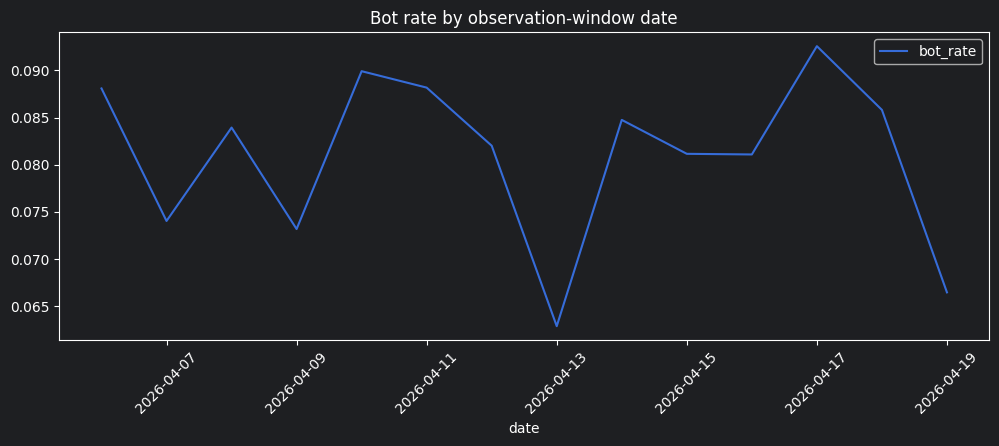

In [51]:
target_by_date.plot(
    x="date",
    y="bot_rate",
    figsize=(12, 4),
    title="Bot rate by observation-window date",
    rot=45,
)

### 22. События внутри окна

In [53]:
def events_in_window(events: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    meta_window = meta[
        ["cookie_id", "window_start_ts", "window_end_ts"]
    ]

    ev = events.merge(
        meta_window,
        on="cookie_id",
        how="inner",
        validate="many_to_one",
    )

    mask = (
        (ev["event_ts"] >= ev["window_start_ts"])
        & (ev["event_ts"] < ev["window_end_ts"])
    )

    return ev.loc[mask].copy()

In [54]:
ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)

print("train events in windows:", len(ev_tr))
print("test events in windows:", len(ev_te))

train events in windows: 198436
test events in windows: 89690


### 23. Coverage внутри окна

In [55]:
train_event_counts = (
    ev_tr.groupby("cookie_id")
    .size()
)

test_event_counts = (
    ev_te.groupby("cookie_id")
    .size()
)

print("TRAIN")
print(train_event_counts.describe())

print("\nTEST")
print(test_event_counts.describe())

TRAIN
count    11091.000000
mean        17.891624
std         17.706829
min          1.000000
25%          6.000000
50%         12.000000
75%         23.000000
max        169.000000
dtype: float64

TEST
count    4909.000000
mean       18.270524
std        18.658159
min         1.000000
25%         6.000000
50%        12.000000
75%        23.000000
max       191.000000
dtype: float64


In [56]:
print(
    "train cookies without events:",
    len(train) - train["cookie_id"].isin(train_event_counts.index).sum()
)

print(
    "test cookies without events:",
    len(test) - test["cookie_id"].isin(test_event_counts.index).sum()
)

train cookies without events: 0
test cookies without events: 0


### 24. События до/после окна

In [80]:
train_window = train[
    ["cookie_id", "window_start_ts", "window_end_ts"]
]

ev_with_window = events.merge(
    train_window,
    on="cookie_id",
    how="inner",
    validate="many_to_one",
)

before_window = (
    ev_with_window["event_ts"] < ev_with_window["window_start_ts"]
)

inside_window = (
    (ev_with_window["event_ts"] >= ev_with_window["window_start_ts"])
    & (ev_with_window["event_ts"] < ev_with_window["window_end_ts"])
)

after_window = (
    ev_with_window["event_ts"] >= ev_with_window["window_end_ts"]
)

print("TRAIN")
print("before:", before_window.sum())
print("inside:", inside_window.sum())
print("after:", after_window.sum())

TRAIN
before: 0
inside: 198436
after: 40779


In [81]:
test_window = test[
    ["cookie_id", "window_start_ts", "window_end_ts"]
]

ev_with_window_test = events.merge(
    test_window,
    on="cookie_id",
    how="inner",
    validate="many_to_one",
)

before_window_test = (
    ev_with_window_test["event_ts"] < ev_with_window_test["window_start_ts"]
)

inside_window_test = (
    (ev_with_window_test["event_ts"] >= ev_with_window_test["window_start_ts"])
    & (ev_with_window_test["event_ts"] < ev_with_window_test["window_end_ts"])
)

after_window_test = (
    ev_with_window_test["event_ts"] >= ev_with_window_test["window_end_ts"]
)

print("TEST")
print("before:", before_window_test.sum())
print("inside:", inside_window_test.sum())
print("after:", after_window_test.sum())

TEST
before: 0
inside: 89690
after: 0


### 25. Сохранить аудит

In [58]:
audit_summary = {
    "train_rows": len(train),
    "test_rows": len(test),
    "events_rows": len(events),
    "train_unique_cookies": train["cookie_id"].nunique(),
    "test_unique_cookies": test["cookie_id"].nunique(),
    "train_positive_rate": train["target"].mean(),
    "event_types": events["event_name"].nunique(),
    "platform_values": events["platform"].nunique(),
    "user_agents": events["user_agent"].nunique(),
    "exact_event_duplicates": events.duplicated().sum(),
    "train_events_in_window": len(ev_tr),
    "test_events_in_window": len(ev_te),
}

pd.Series(audit_summary)

train_rows                 11091.000000
test_rows                   4909.000000
events_rows               328905.000000
train_unique_cookies       11091.000000
test_unique_cookies         4909.000000
train_positive_rate            0.081057
event_types                   10.000000
platform_values               11.000000
user_agents                  148.000000
exact_event_duplicates      4863.000000
train_events_in_window    198436.000000
test_events_in_window      89690.000000
dtype: float64

In [87]:
event_field_availability = (
    events
    .groupby("event_name")[
        [
            "item_id",
            "item_category",
            "item_location",
            "seller_type",
            "search_query",
            "search_page",
            "pointer_x",
            "pointer_y",
        ]
    ]
    .apply(lambda x: x.notna().mean())
)

event_field_availability.round(3)

,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,
captcha_shown,0.0,0.000,0.000,0.000,0.0,0.0,0.272,0.272
contact_chat_open,1.0,0.941,0.969,0.915,0.0,0.0,0.308,0.308
contact_message_sent,1.0,0.939,0.971,0.909,0.0,0.0,0.323,0.323
contact_phone_show,1.0,0.941,0.971,0.907,0.0,0.0,0.323,0.323
favorite_add,1.0,0.937,0.972,0.908,0.0,0.0,0.349,0.349
item_view,1.0,0.941,0.970,0.910,0.0,0.0,0.327,0.327
login,0.0,0.000,0.000,0.000,0.0,0.0,0.353,0.353
photo_swipe,1.0,0.942,0.968,0.912,0.0,0.0,0.342,0.342
search_results_view,0.0,0.940,0.969,0.000,1.0,1.0,0.330,0.330


In [88]:
event_counts = (
    events["event_name"]
    .value_counts()
    .rename("n_events")
)

event_field_availability = (
    event_field_availability
    .join(event_counts)
    .sort_values("n_events", ascending=False)
)

event_field_availability.round(3)

,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,n_events
event_name,,,,,,,,,
item_view,1.0,0.941,0.970,0.910,0.0,0.0,0.327,0.327,120817
search_results_view,0.0,0.940,0.969,0.000,1.0,1.0,0.330,0.330,100402
photo_swipe,1.0,0.942,0.968,0.912,0.0,0.0,0.342,0.342,36517
favorite_add,1.0,0.937,0.972,0.908,0.0,0.0,0.349,0.349,19049
seller_page_view,1.0,0.942,0.969,0.911,0.0,0.0,0.336,0.336,17403
contact_phone_show,1.0,0.941,0.971,0.907,0.0,0.0,0.323,0.323,11316
captcha_shown,0.0,0.000,0.000,0.000,0.0,0.0,0.272,0.272,7928
login,0.0,0.000,0.000,0.000,0.0,0.0,0.353,0.353,6267
contact_chat_open,1.0,0.941,0.969,0.915,0.0,0.0,0.308,0.308,6125


In [89]:
train_event_counts = (
    ev_tr
    .groupby("cookie_id")
    .size()
    .rename("n_events")
)

train_eda = (
    train[["cookie_id", "target"]]
    .merge(
        train_event_counts,
        on="cookie_id",
        how="left",
        validate="one_to_one",
    )
)

train_eda.groupby("target")["n_events"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,10192.0,16.869015,16.173297,1.0,6.0,12.0,22.0,140.0
1,899.0,29.484983,27.515182,1.0,11.0,20.0,38.0,169.0


In [90]:
train_eda.groupby("target")["n_events"].median()

target
0    12.0
1    20.0
Name: n_events, dtype: float64

In [91]:
train_eda.groupby("target")["n_events"].mean()

target
0    16.869015
1    29.484983
Name: n_events, dtype: float64